In [1]:
import pandas as pd
columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
    'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B',
    'LSTAT', 'MEDV'
]
house_df = pd.read_csv(
    "housing.csv",
    sep=r"\s+",
    header=None,
    names=columns
)
house_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [2]:
house_df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [3]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    house_df,
    test_size=0.10,
    random_state=42
)

print("Total:", len(house_df))
print("Train:", len(train_df))
print("Test:", len(test_df))

Total: 506
Train: 455
Test: 51


In [4]:
#EDA: Exploratory Data Analysis
house_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [5]:
train_df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000
mean,3.676738,11.838462,11.046220,0.068132,0.555028,6.299426,68.252747,3.826442,9.538462,407.923077,18.418022,355.122945,12.532791,22.694505
std,8.739089,23.716125,6.909613,0.252249,0.116912,0.709285,28.192329,2.168022,8.685534,167.868211,2.198784,93.267606,7.175338,9.317469
min,0.009060,0.000000,0.740000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081005,0.000000,5.130000,0.000000,0.448500,5.888500,43.550000,2.075400,4.000000,279.500000,17.000000,374.960000,6.820000,17.100000
50%,0.269380,0.000000,8.560000,0.000000,0.538000,6.212000,77.000000,3.215700,5.000000,330.000000,19.000000,391.430000,10.970000,21.400000
75%,3.621175,20.000000,18.100000,0.000000,0.627500,6.633000,93.900000,5.344000,24.000000,666.000000,20.200000,396.025000,16.550000,25.750000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [6]:
!pip install plotly matplotlib seaborn --quiet
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [8]:
fig = px.histogram(
    train_df,
    x = 'CRIM',
    nbins = 50,
    title = 'Distribution of Crime Rate'
)
fig.update_layout(bargap = 0.1)
fig.show()

In [11]:
fig = px.histogram(
    train_df,
    x = 'ZN',
    nbins = 30,
    title = 'Distribution of Residential land proportion'
)
fig.update_layout(bargap = 0.1)
fig.show()

In [12]:
fig = px.histogram(
    train_df,
    x = 'INDUS',
    nbins = 30,
    title = 'Distribution of Non-retail business land proportion'
)
fig.update_layout(bargap = 0.1)
fig.show()

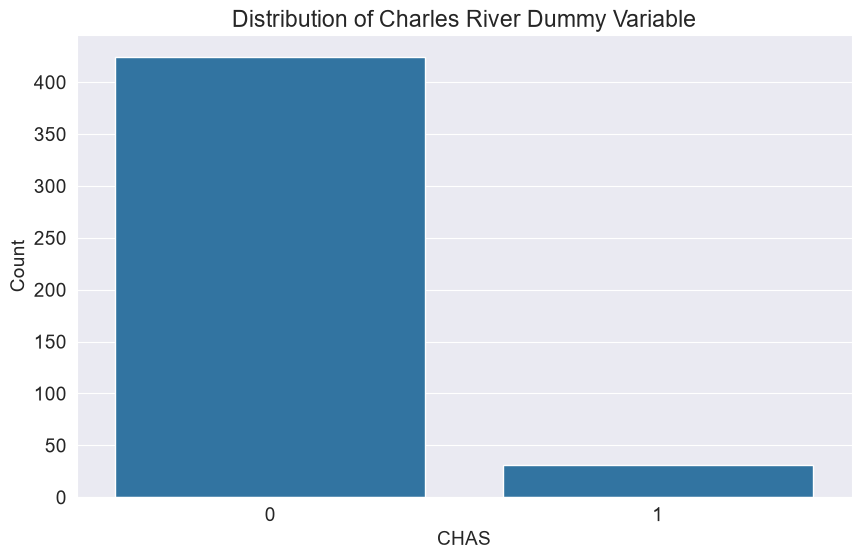

In [17]:
sns.countplot(data=train_df, x='CHAS')
plt.title('Distribution of Charles River Dummy Variable')
plt.xlabel('CHAS')
plt.ylabel('Count')
plt.show()